# 我使用了什么库？

In [23]:
# 需要导入的库

import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc

# 然后，我要干什么？

首先,要了解需要解决什么问题:

**Q**: 什么是分类问题？

**Q**: 什么是二元分类（举例）？

然后和**回归问题**一样，首先要解决**数据生成**和**数据准备**的问题

# 分类问题

**Q**: 分类问题的数据是什么样的？（描述特征和标签存储内容的意义）


## 数据生成

**Q**: 数据生成大体上有几个相关的系数？

**Q**: 数据生成后的首要步骤是什么？

**Q**: 数据生成后的第二个步骤是什么？针对的数据范围是？（Tips: 梯度等高线的形状）

结合代码:

**Q**: 如何制造一组二元分类的数据？参数都是什么意思？

**Q**: 如何拆分二元数据？

**Q**: 复习如何标准化一维数据的？现在如何标准化二维数据？

[-0.0551441  -0.03733246] 1
(100, 2) (100,)
(80, 2) (80,)
(20, 2) (20,)


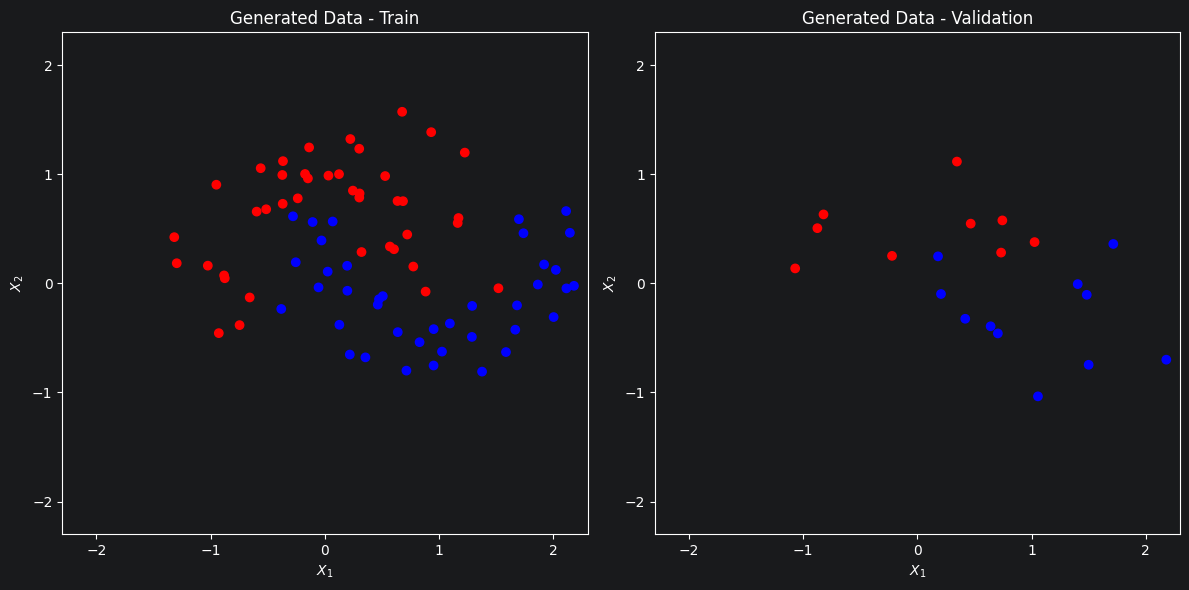

In [24]:
# 程序3-1: 生成分类数据

# 参数: 数量,噪声,种子
x,y = make_moons(n_samples=100,noise=0.3,random_state=0)

# 拆分数据
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=13)

print(x_train[0],y_train[0])

print(x.shape,y.shape)
print(x_train.shape,y_train.shape)
print(x_val.shape,y_val.shape)

# 验证和可视化
from plots.chapter3 import *
fig = figure1(x_train, y_train, x_val, y_val)

## 标准化数据

参考ch00:标准化-归一化-缩放,复习

**Q**: 标准化后的均值和标准差有什么特点？

**Q**: 如何对数据集进行标准化？（均值，标准差，和缩放公式）有什么注意事项？

**Q**: 为什么标准化后的特征对学习有好处？

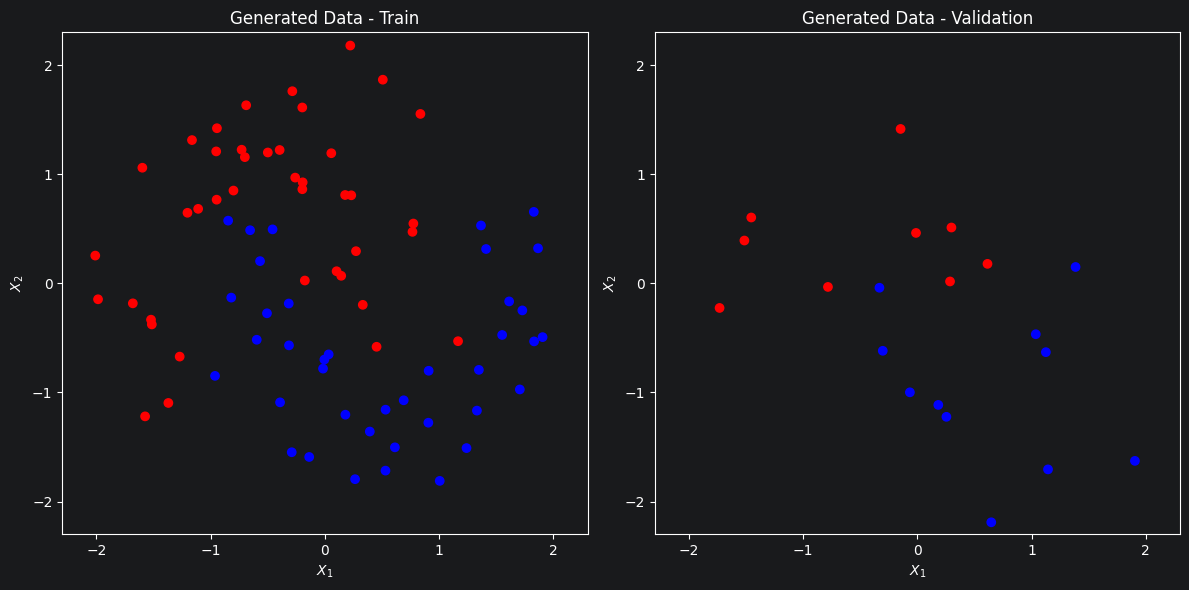

In [25]:
# 程序3-2: 标准化

sc = StandardScaler()
sc.fit(x_train)

x_train = sc.transform(x_train)
x_val = sc.transform(x_val)

fig = figure1(x_train, y_train, x_val, y_val)

## 数据准备

**Q**: 在以前的经历中,数据准备要做哪些事？

结合代码:

**Q**: `reshape`的作用是什么？

**Q**: shuffle与否的标准是什么?

In [26]:
# 程序3-3: 数据准备

# 设置种子
torch.manual_seed(13)

# 构建张量
#print(y_train.shape,y_train.reshape(-1,1).shape)
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train.reshape(-1,1)).float()

x_val_tensor = torch.as_tensor(x_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1,1)).float()

# 构建dataset
train_dataset  = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# 构建dataloader

train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)

# 然后，我要干什么？

在数据工作完成后,之后便是要了解使用的模型，不同于回归时简单的线性回归模型,对于分类问题,使用的是所谓**逻辑斯提(logistic)回归模型**
- 它如何处理分类问题？
- **logit**是什么？

这里设计很多概念，然后: 会去了解与之相关的损失函数：**二元交叉熵损失**，还会讨论不平衡数据集的处理方法

# 模型

## 逻辑斯特回归

**Q**: 复习:线性回归的公式是什么？

**Q**: 如何将线性回归模型映射成离散标签？（以二元为例，公式）

**Q**: `logit(z)`如何用向量表示？

阅读笔记:

**Q**: 在书中,什么是logit(z),什么是logit？

**Q**: logit和线性回归的区别？其不确定性从何而来？

**Q**: 概率在其中的作用是什么？

---


**Q**: 比值比是什么？其作用是什么？图像是什么？

**Q**: 对数比值比是什么？图像是什么？

**Q**: logit值映射到概率的函数需要什么特征？为什么？


3.0 0.3333333333333333


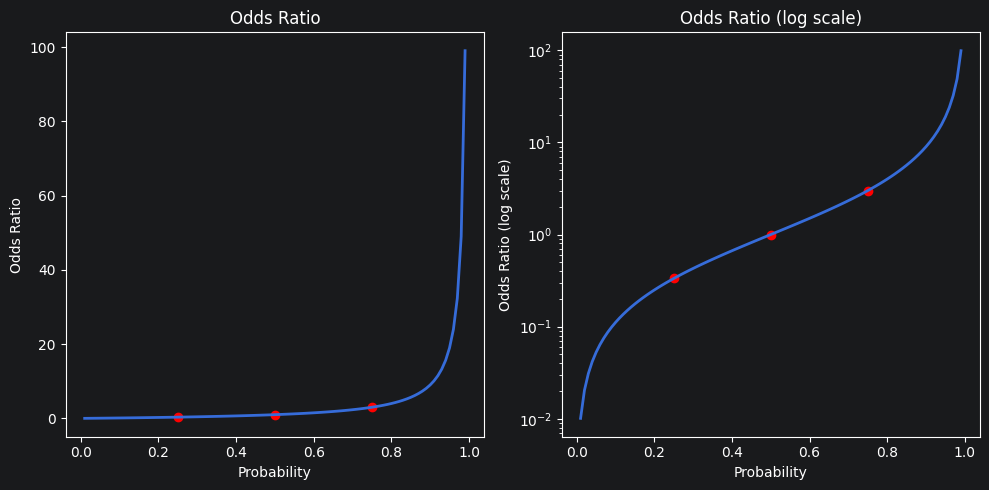

In [27]:
# 程序3-4: 比值比（赔率）
def odds_ratio(prob):
    return prob / (1 - prob)

p = .75
q = 1 - p
print(odds_ratio(p), odds_ratio(q))

# 可视化
fig = figure2(p)

1.0986122886681098 -1.0986122886681098


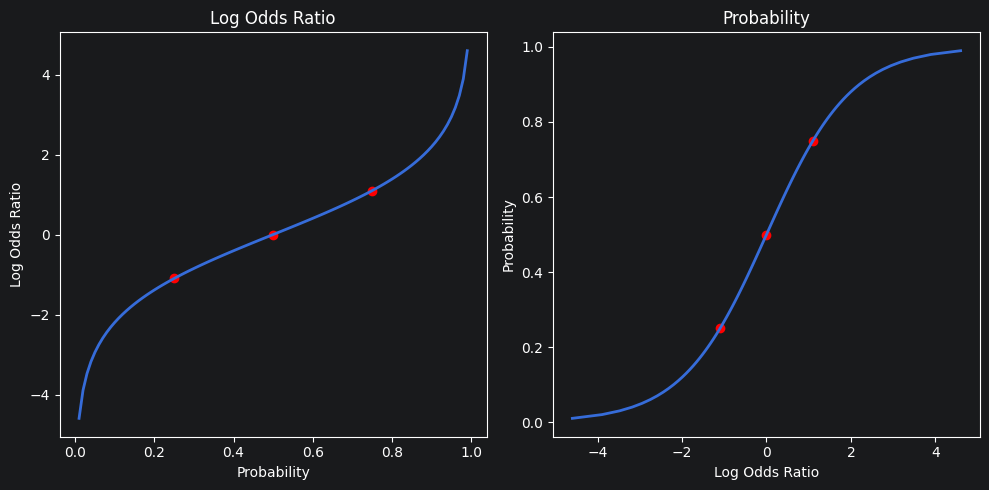

In [28]:
# 程序3-5: 对数比值比和概率
def log_odds_ratio(prob):
    return np.log(odds_ratio(prob))

p = .75
q = 1 - p
print(log_odds_ratio(p), log_odds_ratio(q))

fig = figure3(p)

### note-ch03-1

这里要解释的问题是： 如何将线性回归模型和概率挂钩？

**首先**，线性回归模型是线性的，需要先映射到离散的标签上

![image.png](attachment:ff38cbc0-332a-412e-b261-47a976b5a2d9.png)

对于该函数来说，`y=logit(z)`,`z`就是不等是左边的值，又称为**logit值**

**接着**，该值貌似与线性回归相同且无噪声，那么其**不确定性**如何体现？

对于该函数，我们不说某个点的函数值是哪个离散标签，而是统一返回在该数据点的情况下，结果属于正类的概率，简言就是该**数据点属于正类的概率**。

---

注意，这里的**目标其实是要把`z`的取值映射到概率上**，在上述情况下
- 越大的正`logit`值应该分配较高的概率
- 越大的负`logit`值应该分配较低的概率
- 0.5概率的情况发生在`z=0`的情况上

对于概率，有一条简单粗暴的总结：**概率就是面积！**

可以从下图看到，这其实就是`z>=0`的区域
![image.png](attachment:d8f69033-c922-4207-84b1-89cfc566e2ba.png)

在直观上:
- 把整个平面看成是全部概率，即1,
- z的每个值都是平行线，构成了红色的区域
- `z=0`正好是一半的分界线,红色的面积=白色面积=0.5

综上，要求的**正类概率就是左下到z实际值的那条线占总的面积**
- 这样就把线性的logit值和概率挂上了钩




## Sigmoid函数

**Q**: logit如何通过对数比值比映射到概率？


结合代码:

**Q**: torch的sigmoid如何使用？（两种方法）第二种方法的作用是？

In [29]:
# 程序3-6: sigmoid

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p = .75
q = 1 - p
print(sigmoid(log_odds_ratio(p)), sigmoid(log_odds_ratio(q)))

0.75 0.25


tensor(0.7500) tensor(0.2500)


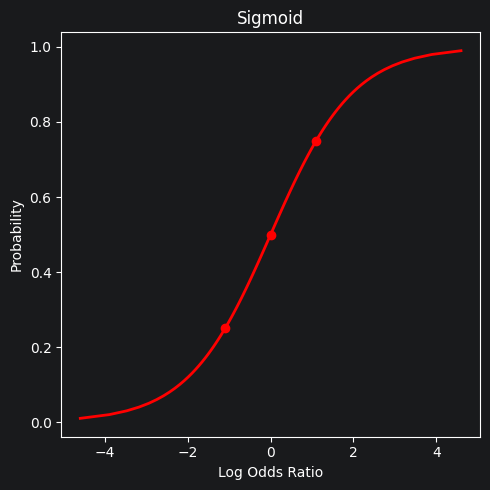

In [30]:
# 程序3-7: torch的sigmoid(只展示方法1)

print(torch.sigmoid(torch.tensor(1.0986)), torch.sigmoid(torch.tensor(-1.0986)))

fig = figure4(p)

## 非线性函数

**Q**: sigmoid函数有什么特点？

**Q**: 激活函数是什么？有什么特点？

**Q**: 非线性函数的意义？

结合代码:

**Q**: 逻辑斯蒂回归如何用层来实现？

In [31]:
# 程序3-8: 逻辑斯蒂回归

torch.manual_seed(42)

model1 = nn.Sequential()
model1.add_module("linear",nn.Linear(2,1))
model1.add_module("sigmoid",nn.Sigmoid())

print(model1.state_dict())

OrderedDict([('linear.weight', tensor([[0.5406, 0.5869]])), ('linear.bias', tensor([-0.1657]))])


# 损失函数

**Q**: 二元分类的损失函数是什么？（别名:对数损失,BCE）

**Q**: BCE的公式是什么？（直观方法和通用公式）

**Q**: 对于负类的概率如何处理？

结合代码:

**Q**: BCE的公式是什么？（直观方法和通用公式）

**Q**: nn的BCE如何定义和使用？参数的意义？




In [33]:
# 程序3-9: BCE损失函数 (直观)

dummy_labels = torch.tensor([1.,0.])
dummy_preds = torch.tensor([.9,.2])

print(dummy_labels == 1,dummy_labels == 0)
# 正类
pos_pred = dummy_preds[dummy_labels == 1]
first_sum = torch.log(pos_pred).sum()

# 负类
neg_pred = dummy_preds[dummy_labels == 0]
second_sum = torch.log(1-neg_pred).sum()

n_total = dummy_labels.size(0)

loss = -(first_sum + second_sum)/n_total

print(loss)



tensor([ True, False]) tensor([False,  True])
tensor(0.1643)


In [35]:
# 程序3-10: BCE损失函数 (通用)

summation = torch.sum(
    dummy_labels * torch.log(dummy_preds) +
    (1 - dummy_labels) * torch.log(1 - dummy_preds)
)
loss = -summation / n_total
print(loss)


tensor(0.1643)


In [37]:
# 程序3-10: BCE损失函数 (封装函数)

loss_fn = nn.BCELoss(reduction='mean')


# 注意:预测在前,labels在后

print(loss_fn(dummy_preds, dummy_labels))

print(loss_fn(dummy_labels, dummy_preds))

tensor(0.1643)
tensor(15.0000)


# 不平衡的数据集

## BCEWithLogitsloss

结合代码

**Q**: `BCEWithLogitsloss`和`BCELoss`的区别是什么？

**Q**: 对层的设计有什么影响？

**Q**: `BCEWithLogitsloss`参数的都有什么意义？

In [39]:
# 程序3-11: BCEWithLogitsloss损失函数 (封装函数)

loss_fn_logits = nn.BCEWithLogitsLoss(reduction='mean')

logit1 = log_odds_ratio(.9)
logit2 = log_odds_ratio(.2)


dummy_labels = torch.tensor([1.,0.])
dummy_logits = torch.tensor([logit1,logit2])

print(dummy_logits)

loss = loss_fn_logits(dummy_logits, dummy_labels)

print(loss)


tensor([ 2.1972, -1.3863], dtype=torch.float64)
tensor(0.1643)


## 不平衡的数据集

**Q**: 如何是不平衡的数据集，举例说明？

**Q**: `BCEWithLogitsloss`的`pos_wegiht`参数如何设置（公式，张量的长度）？

结合代码:

**Q**: `BCEWithLogitsloss`对于`pos_wegiht`的计算有什么怪癖？

In [47]:
# 程序3-12: 不平衡数据集的BCEWithLogitsloss

dummy_imb_labels = torch.tensor([1.0, 0.0, 0.0, 0.0])
dummy_imb_logits = torch.tensor([logit1, logit2, logit2, logit2])


# 计算参数
n_neg = (dummy_imb_labels == 0).sum().float()
n_pos = (dummy_imb_labels == 1).sum().float()

pos_wight = (n_neg / n_pos).view(1,)

print(pos_wight)


# 怪癖？
loss_fn_imb = nn.BCEWithLogitsLoss(reduction='mean',pos_weight=pos_wight)

loss = loss_fn_imb(dummy_imb_logits, dummy_imb_labels)
print(loss)


# 怪癖的处理方法
loss_fn_imb_sum = nn.BCEWithLogitsLoss(reduction='sum',pos_weight=pos_wight)

loss = loss_fn_imb_sum(dummy_imb_logits, dummy_imb_labels)

loss = loss / (pos_wight * n_pos + n_neg)

print(loss)



tensor([3.])
tensor(0.2464)
tensor([0.1643])


# 然后，我要干什么？

接下来要用之前的模型配置和模型训练解决分类的问题

# 模型配置和模型训练

结合代码:

**Q**: 看看什么变了，什么没变？